In [1]:
!pip install darts

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.3/60.3 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.4/825.4 kB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 46.6 MB/s eta 0:00:00


In [2]:
!pip install astsadata

In [3]:
import numpy as np
import pandas as pd

import IPython.display as dp
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
sns.despine()

plt.rc("figure", figsize=(12, 8))
plt.rc("font", size=13)

%matplotlib inline

<Figure size 640x480 with 0 Axes>

In [4]:
from darts import TimeSeries
import darts.datasets as ds
import scipy.stats as sts
import statsmodels.api as sm
import statsmodels.tsa.api as tsa
from darts.utils.statistics import plot_acf, plot_pacf, check_seasonality
import numpy as np
import pandas as pd

## Forecasting hierarchical time series

We often want to forecast multiple time series that have hierarchical structure, e.g. sales grouped by store, country. The problem is to make the forecasts agree, e.g. so that sales in stores of a country sum to the sales in this country.

In [5]:
from darts.datasets import AustralianTourismDataset

In [6]:
tourism = AustralianTourismDataset().load()

In [7]:
tourism.to_dataframe().head()

,Total,Hol,VFR,Bus,Oth,NSW - hol,VIC - hol,QLD - hol,SA - hol,WA - hol,...,TAS - oth - noncity,NT - oth - city,NT - oth - noncity,NSW,VIC,QLD,SA,WA,TAS,NT
0,84503.0,45906.0,26042.0,9815.0,2740.0,17589.0,10412.0,9078.0,3089.0,3449.0,...,24.0,35.0,8.0,30778.0,19020.0,17163.0,6443.0,6841.0,3775.0,483.0
1,65312.0,29347.0,20676.0,11823.0,3466.0,11027.0,6025.0,6310.0,1935.0,2454.0,...,61.0,69.0,39.0,24395.0,12509.0,14275.0,4492.0,6119.0,2091.0,1431.0
2,72753.0,32492.0,20582.0,13565.0,6114.0,8910.0,5060.0,11733.0,1569.0,3398.0,...,23.0,150.0,338.0,21713.0,11261.0,22035.0,4484.0,8191.0,1207.0,3862.0
3,70880.0,31813.0,21613.0,11478.0,5976.0,10658.0,5481.0,8109.0,2270.0,3561.0,...,43.0,172.0,453.0,24326.0,12930.0,16179.0,4823.0,8615.0,2103.0,1904.0
4,86893.0,46793.0,26947.0,10027.0,3126.0,16152.0,10958.0,10047.0,3023.0,4287.0,...,60.0,15.0,47.0,30869.0,19190.0,19449.0,5554.0,7526.0,3369.0,936.0


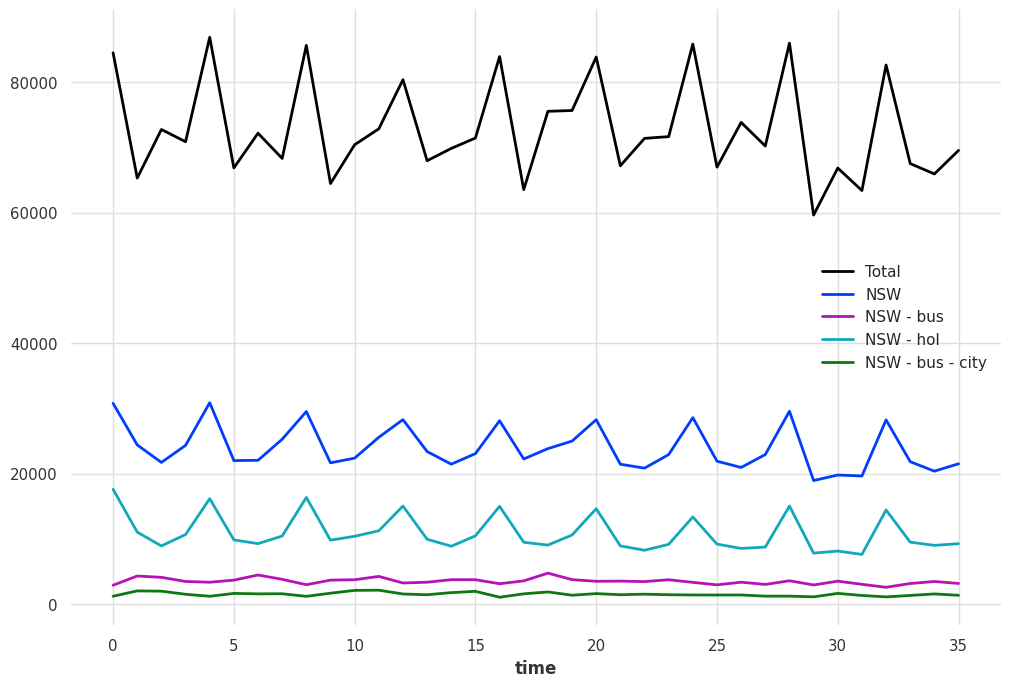

In [8]:
tourism[["Total", "NSW", "NSW - bus", "NSW - hol", "NSW - bus - city"]].plot();

In [9]:
reasons = ["Hol", "VFR", "Bus", "Oth"]
regions = ["NSW", "VIC", "QLD", "SA", "WA", "TAS", "NT"]
city_labels = ["city", "noncity"]

In [10]:
from itertools import product

In [11]:
hierarchy = dict()

for reason in reasons:
    hierarchy[reason] = ["Total"]

for region in regions:
    hierarchy[region] = ["Total"]

for region, reason in product(regions, reasons):
    hierarchy["{} - {}".format(region, reason.lower())] = [reason, region]

for region, reason, city in product(regions, reasons, city_labels):
    hierarchy["{} - {} - {}".format(region, reason.lower(), city)] = [
        "{} - {}".format(region, reason.lower())
    ]

In [12]:
tourism = tourism.with_hierarchy(hierarchy)

In [13]:
train, val = tourism[:-12], tourism[-12:]

In [14]:
from darts.models import LinearRegressionModel

In [25]:
model = LinearRegressionModel(lags=6)
model.fit(train)
pred = model.predict(n=len(val))

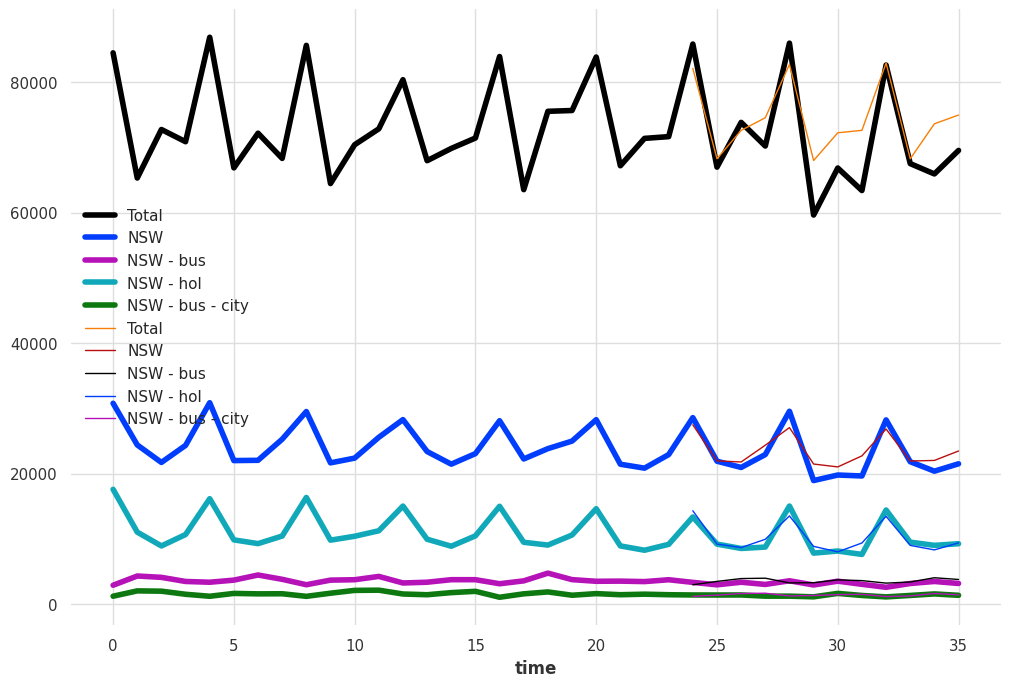

In [26]:
components_to_show = ["Total", "NSW", "NSW - bus", "NSW - hol", "NSW - bus - city"]
plt.figure()
tourism[components_to_show].plot(lw=4)
pred[components_to_show].plot(lw=1);

In [27]:
regions_reasons_comps = list(
    map(lambda t: "{} - {}".format(t[0], t[1].lower()), product(regions, reasons))
)

regions_reasons_city_comps = list(
    map(
        lambda t: "{} - {} - {}".format(t[0], t[1].lower(), t[2]),
        product(regions, reasons, city_labels),
    )
)

<Axes: xlabel='time'>

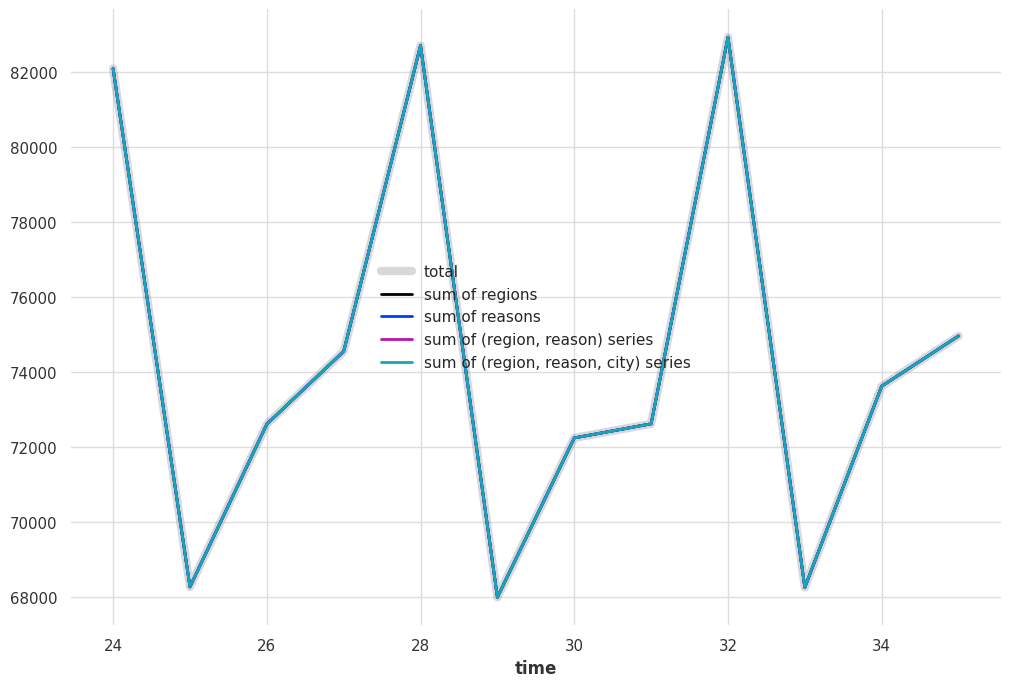

In [28]:
pred["Total"].plot(label="total", lw=6, alpha=0.3, color="grey")
sum([pred[r] for r in regions]).plot(label="sum of regions")
sum([pred[r] for r in reasons]).plot(label="sum of reasons")
sum([pred[t] for t in regions_reasons_comps]).plot(
    label="sum of (region, reason) series"
)
sum([pred[t] for t in regions_reasons_city_comps]).plot(
    label="sum of (region, reason, city) series"
)

## Forecasting hierarchical time series: single level approaches

Traditionally, forecasts of hierarchical time series involved selecting one level of aggregation and generating forecasts for that level. These are then either aggregated for higher levels, or disaggregated for lower levels.

- Top-down approach: forecast series at bottom level, then sum to obtain higher levels
- Bottom-up approach: forecast series at upper level, then split in fitted proportions to obtain lower levels

In [29]:
from darts.dataprocessing.transformers import BottomUpReconciliator

In [30]:
reconciliator = BottomUpReconciliator()
reconcilied_preds = reconciliator.transform(pred)

<Axes: xlabel='time'>

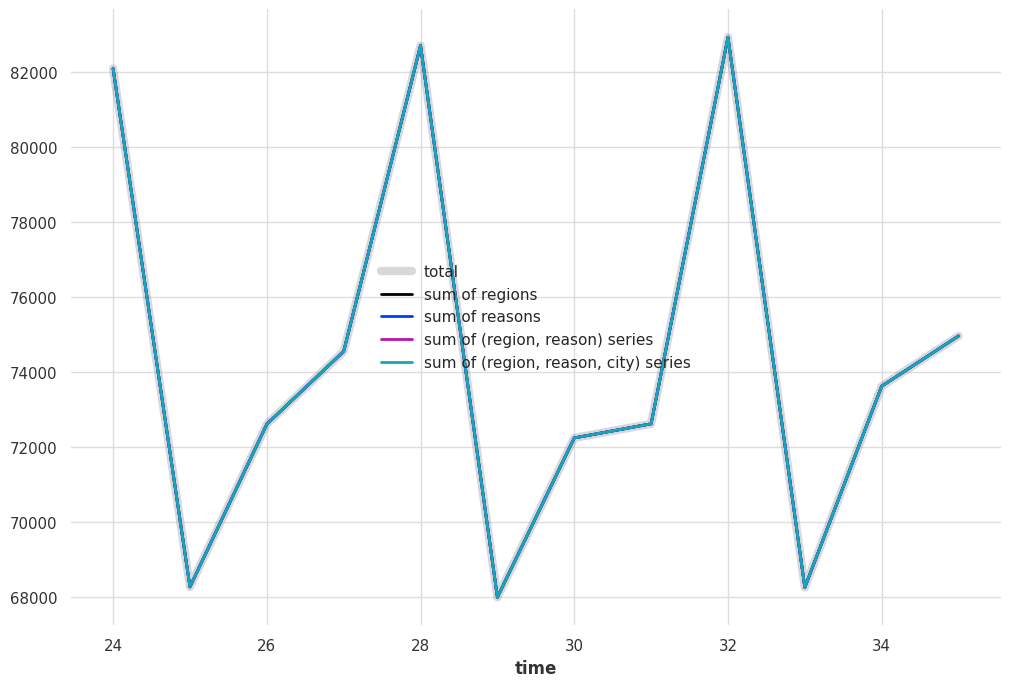

In [31]:
reconcilied_preds["Total"].plot(label="total", lw=6, alpha=0.3, color="grey")
sum([reconcilied_preds[r] for r in regions]).plot(label="sum of regions")
sum([reconcilied_preds[r] for r in reasons]).plot(label="sum of reasons")
sum([reconcilied_preds[t] for t in regions_reasons_comps]).plot(
    label="sum of (region, reason) series"
)
sum([reconcilied_preds[t] for t in regions_reasons_city_comps]).plot(
    label="sum of (region, reason, city) series"
)

## Forecasting hierarchical time series: optimal forecast reconciliation

Forecast all levels, then use regression to reconcile.

In [32]:
from darts.dataprocessing.transformers import MinTReconciliator

In [33]:
reconciliator = MinTReconciliator(method="wls_val")
reconciliator.fit(train)
reconcilied_preds = reconciliator.transform(pred)

<Axes: xlabel='time'>

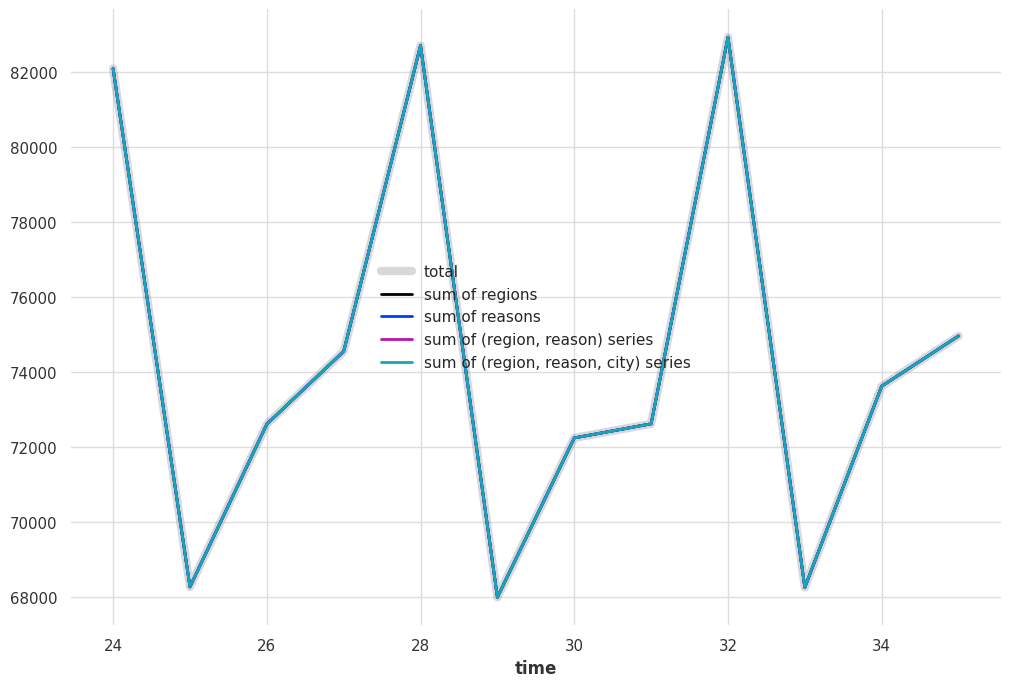

In [34]:
reconcilied_preds["Total"].plot(label="total", lw=6, alpha=0.3, color="grey")
sum([reconcilied_preds[r] for r in regions]).plot(label="sum of regions")
sum([reconcilied_preds[r] for r in reasons]).plot(label="sum of reasons")
sum([reconcilied_preds[t] for t in regions_reasons_comps]).plot(
    label="sum of (region, reason) series"
)
sum([reconcilied_preds[t] for t in regions_reasons_city_comps]).plot(
    label="sum of (region, reason, city) series"
)

## Pipeline of working with time series

- Visualize data, analyze the distribution of the feature. In case the variance is not constant, make a transformation (e.g. log). Check for and remove outliers.
- Estimate ARIMA: plot ACF/PACF, find starting parameters $p$, $q$, look for better parameters in their proximity. Check the residuals. Estimate AutoARIMA, check if it is adequate, check the residuals.
- Estimate ETS: use AutoETS to find the optimal combination of trend/seasonality/error. Check if it is adequate, check the residuals.
- Visual analysis of the forecast, if necessary - check for necessity of a combined model.
- Compare the models and pick the best. Make conclusions.

In [40]:
salaries = pd.read_csv("median-wages.csv", encoding='cp1251', sep=";")

In [42]:
salaries.head()

,date,category,value
0,2025-04-30,Все отрасли,58207
1,2025-04-30,Спорт и досуг,46427
2,2025-04-30,Здравоохранение,48880
3,2025-04-30,Образование,45517
4,2025-04-30,Гос. управление,60000


In [43]:
salaries = salaries.loc[salaries["category"] == "Все отрасли", ["date", "value"]]

In [44]:
salaries_ts = TimeSeries.from_dataframe(salaries, time_col="date", value_cols=["value"])

<Axes: xlabel='date'>

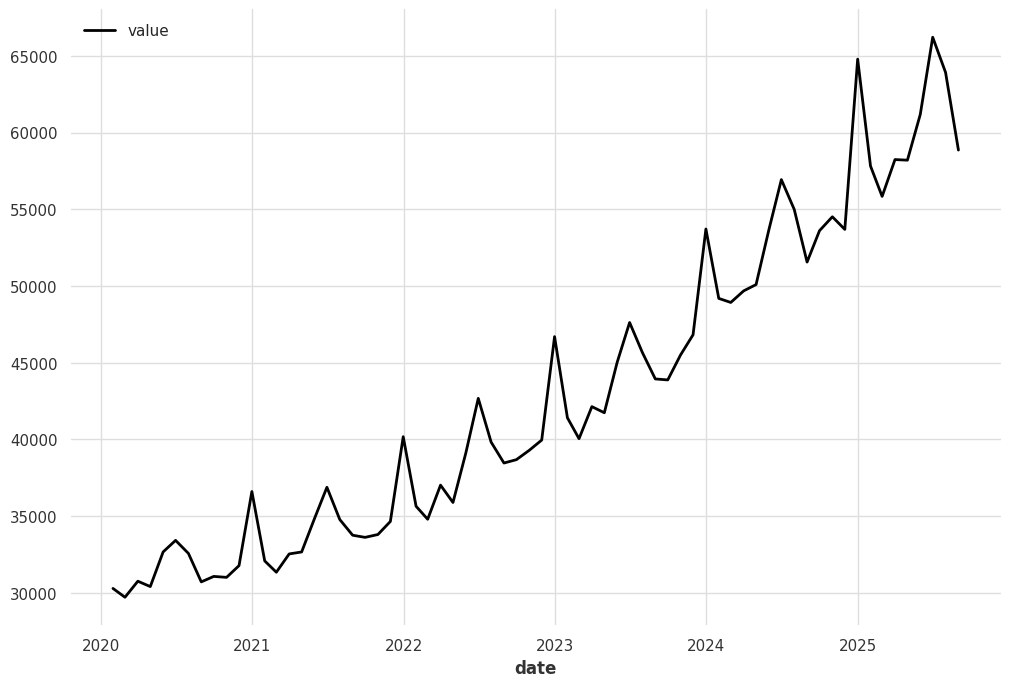

In [45]:
salaries_ts.plot()

(array([14., 12.,  9.,  6.,  6.,  5.,  6.,  6.,  1.,  3.]),
 array([29715. , 33365.5, 37016. , 40666.5, 44317. , 47967.5, 51618. ,
        55268.5, 58919. , 62569.5, 66220. ]),
 <BarContainer object of 10 artists>)

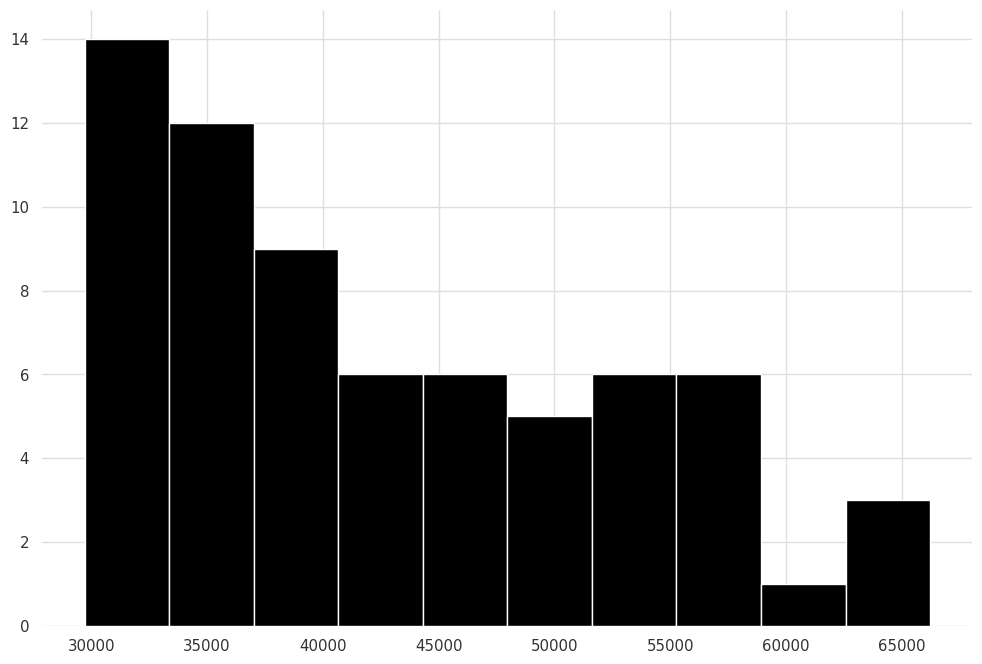

In [46]:
plt.hist(salaries_ts.values())

In [47]:
salaries_ts_log = salaries_ts.map(lambda ts: np.log(ts))

<Axes: xlabel='date'>

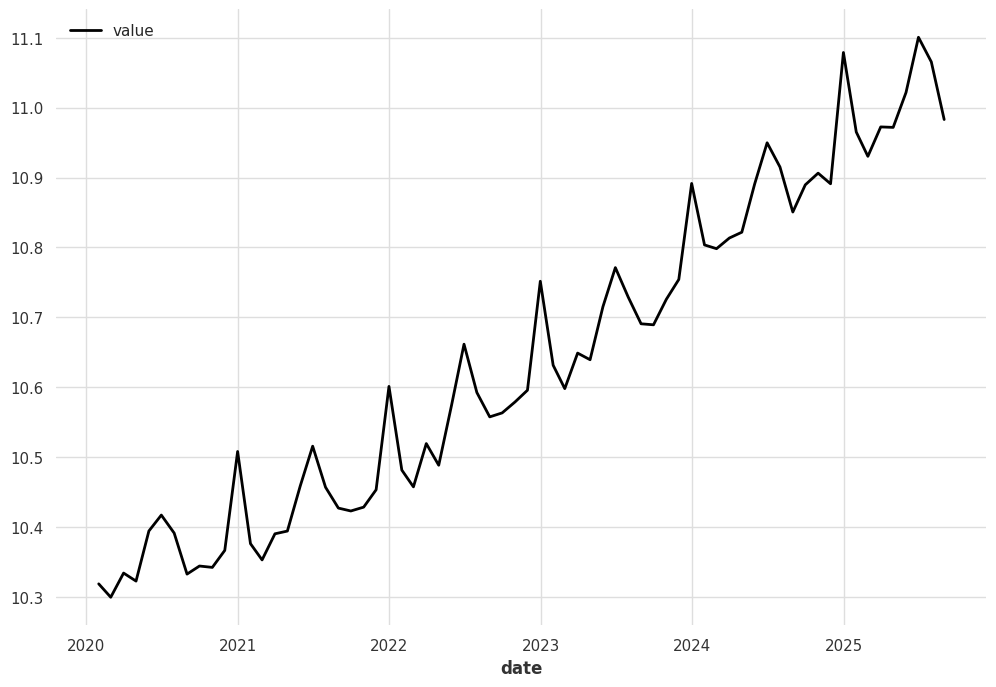

In [48]:
salaries_ts_log.plot()

(array([10., 12.,  5.,  8.,  6.,  6.,  5.,  7.,  5.,  4.]),
 array([10.29940725, 10.3795403 , 10.45967336, 10.53980642, 10.61993947,
        10.70007253, 10.78020559, 10.86033864, 10.9404717 , 11.02060475,
        11.10073781]),
 <BarContainer object of 10 artists>)

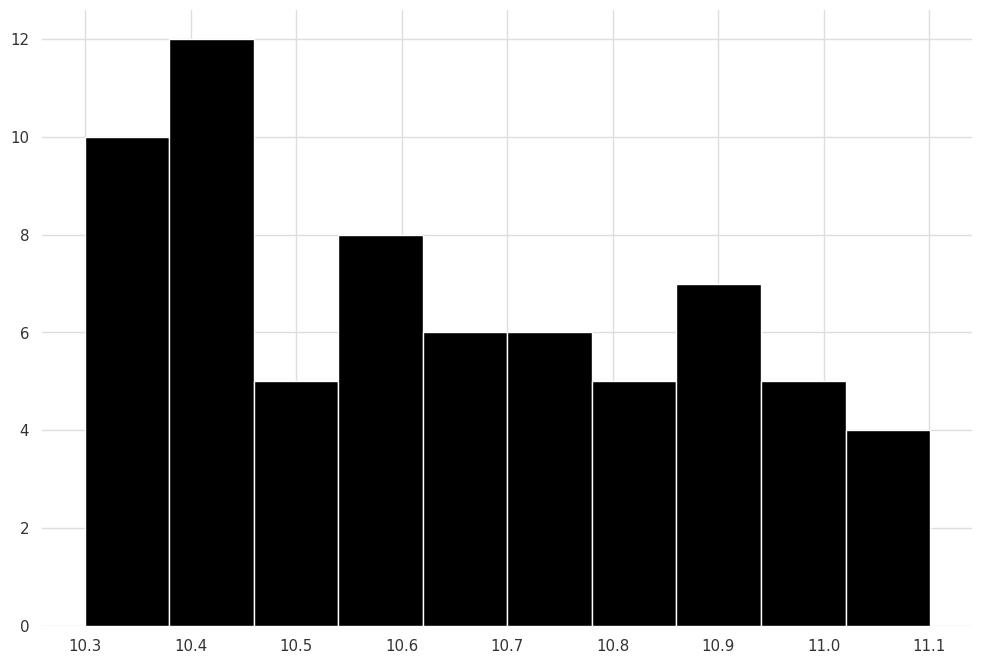

In [49]:
plt.hist(salaries_ts_log.values())

In [52]:
salaries_ts_log.freq

<MonthEnd>

<Axes: xlabel='date'>

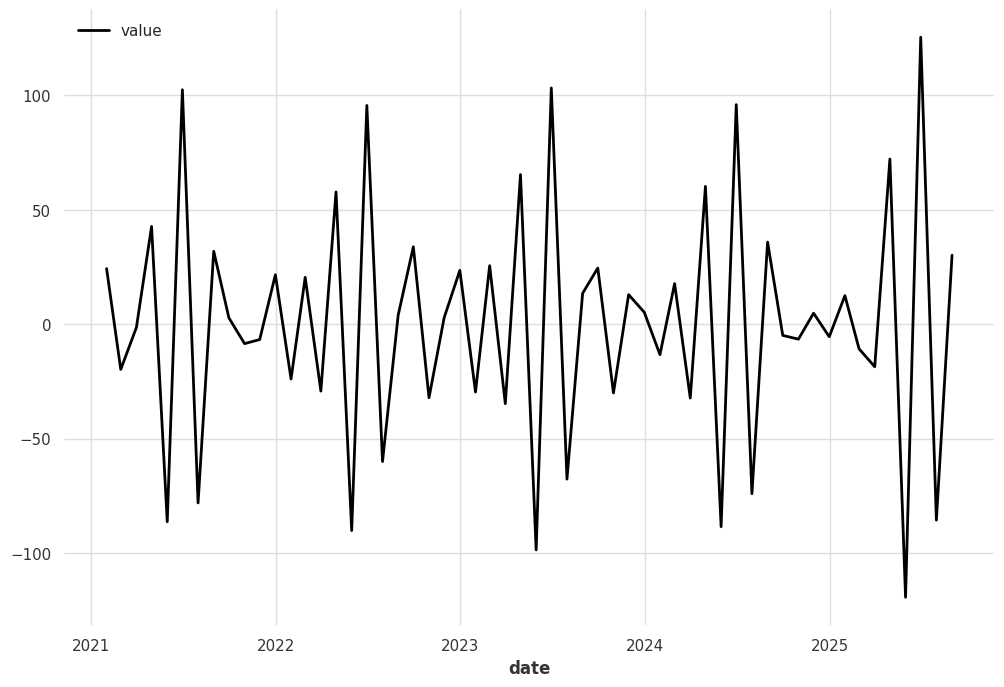

In [51]:
salaries_ts_log.diff(12).plot()

In [53]:
_, pvalue, _, _ = tsa.stattools.kpss(salaries_ts_log.diff(12).values())
pvalue

/tmp/ipython-input-2998096733.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  _, pvalue, _, _ = tsa.stattools.kpss(salaries_ts_log.diff(12).values())


np.float64(0.1)

In [54]:
pvalue < 0.05

np.False_

In [55]:
# S = 12
# D = 1
# d = 0

In [56]:
salaries_ts_log_diff = salaries_ts_log.diff(12)

In [57]:
from darts.utils.statistics import plot_acf, plot_pacf

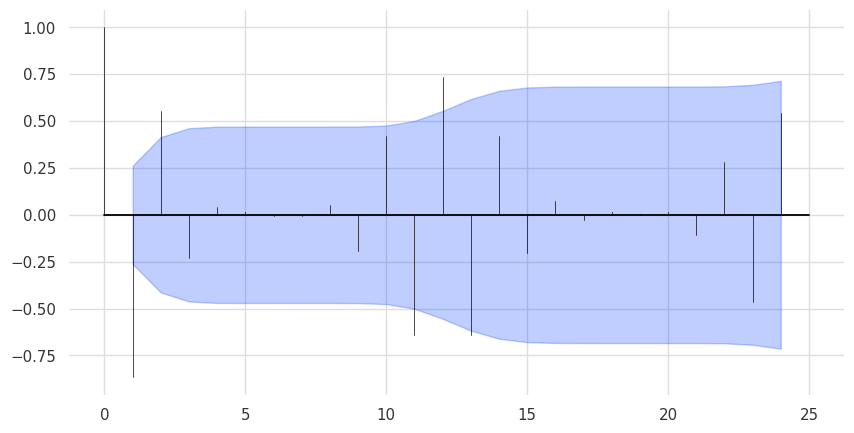

In [58]:
plot_acf(salaries_ts_log_diff)

In [59]:
# q = 2
# S = 12
# Q = 1

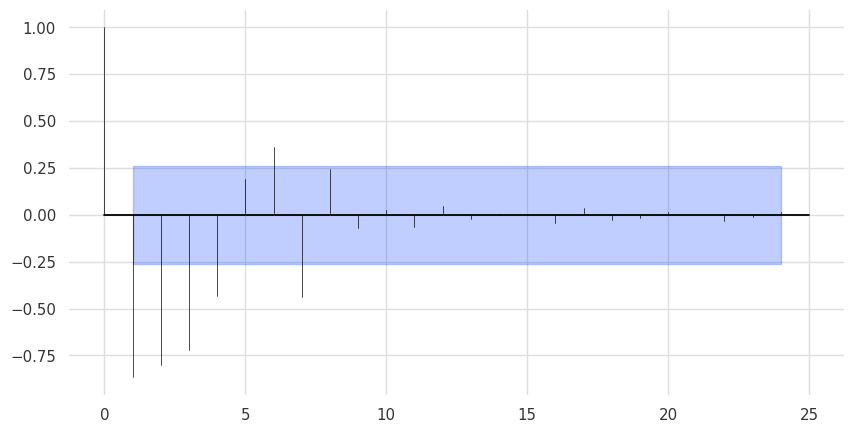

In [62]:
plot_pacf(salaries_ts_log_diff, method="ywm")

In [63]:
# p = 4
# P = 0

In [65]:
from darts.models import ARIMA

In [161]:
arima = ARIMA(p=3, d=0, q=2, seasonal_order=(0, 1, 1, 12))

In [162]:
arima.fit(salaries_ts_log)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMA(p=3, d=0, q=2, seasonal_order=(0, 1, 1, 12), trend=None, random_state=None, add_encoders=None)

In [163]:
from darts.models import AutoARIMA

In [151]:
auto_arima = AutoARIMA(season_length=12)
auto_arima.fit(salaries_ts_log)

AutoARIMA(add_encoders=None, quantiles=None, random_state=None, season_length=12)

In [146]:
def test_residuals(resid):
  fig, ax = plt.subplots(1,2,figsize=(12,5))
  ax[0].hist(resid.values());
  ax[1].stem(resid.values());
  plt.show();

  pvalue = sts.ttest_1samp(resid.values(), 0).pvalue
  rejected = pvalue < 0.05
  print("zero mean" if not rejected else "non-zero mean")

  pvalue = tsa.stattools.kpss(resid.values())[1]
  rejected = pvalue < 0.05
  print("stationary" if not rejected else "non-stationary")

  sm.stats.acorr_ljungbox(resid.values(), model_df=1)["lb_pvalue"].max()
  rejected = pvalue < 0.05
  print("there is", "no autocorrelation" if not rejected else "autocorrelation")

  pvalue = sts.shapiro(resid.values()).pvalue
  rejected = pvalue < 0.05
  print("normal" if not rejected else "not normal")

  r = resid.to_series()
  trend = pd.Series(np.arange(len(r)), index=r.index, name="trend")
  month_dums = pd.get_dummies(r.index.month.astype("category"), prefix="m", drop_first=True)
  month_dums.index = r.index
  X = pd.concat([trend, month_dums], axis=1)
  X = sm.add_constant(X)
  _, lm_pvalue, _, _ = sm.stats.diagnostic.het_breuschpagan(r.values, X.values) # null: does not depend
  rejected = lm_pvalue < 0.05
  print("homoscedastic" if not rejected else "heteroscedastic")

In [164]:
resid = arima.model.resid

In [157]:
resid = auto_arima.model.model_["residuals"]

In [165]:
len(resid) == len(salaries_ts_log)

True

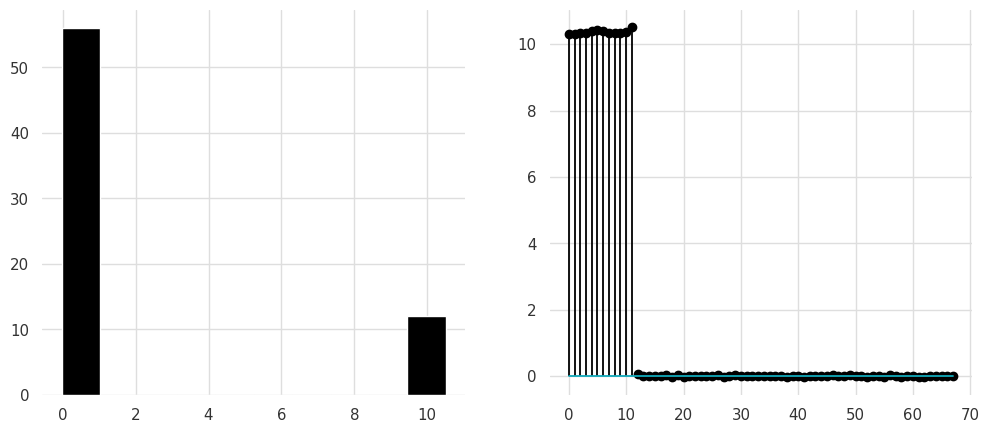

non-zero mean
non-stationary
there is autocorrelation
not normal
heteroscedastic


In [166]:
test_residuals(TimeSeries(values=resid, times=salaries_ts_log.to_series().index))

## Spectral representation

$$
    X_t = \sum_{j=1}^k R_j \cos (\omega_j t + \phi_j) + Z_t
$$
with $\mathbb{E}[R_j] = 0$ or $\phi_j \sim U[0, 2\pi]$

## Wiener–Khinchin theorem

$$
    \gamma(k) = \int_0^\pi \cos \omega k {\rm d} F(\omega)
$$
where $F(\omega)$ is called **spectral distribution function**.

## Spectral Distribution Function

Properties:
- $F(\omega)$ is monotonically increasing
- $F(0) = 0$
- $F(\pi) = \mathbb{V}\text{ar}(X_t) = \sigma_X^2$

Interpretation: $F(\omega)$ is the contribution to the variance of the series, which is accounted for by frequencies in the range $(0, \omega)$.

## Spectral Density Function

$$
    f(\omega) = F'(\omega)
$$

$$
    \gamma(k) = \int_0^\pi \cos \omega k f(\omega) {\rm d} \omega
$$

$$
    f(\omega) = \frac1\pi \sum_{k=-\infty}^\infty \gamma(k) e^{- i\omega k} = \frac1\pi \left( \gamma(0) + 2 \sum_{k=1}^\infty \gamma(k) \cos{\omega k} \right)
$$

## Example 1: spectrum of white noise

For white noise $Z_t$ with $\mathbb{V}\text{ar}(Z_t) = \sigma^2_Z$, using
$$
    f(\omega) = \frac1\pi \left( \gamma(0) + 2 \sum_{k=1}^\infty \gamma(k) \cos{\omega k} \right) = \gamma(0) / \pi = \sigma^2_Z / \pi
$$

## Example 2: spectrum of MA(1)

Consider $X_t = Z_t + \beta Z_{t-1}$. We know its ACF:
$$
    \rho(k) = \begin{cases}
        1, \; k = 0, \\
        \beta / (1 + \beta^2), \; k = \pm 1, \\
        0, \; \text{else}
    \end{cases}
$$

Using
$$
    f^\ast(\omega) = \frac1\pi \left( 1 + 2 \sum_{k=1}^\infty \rho(k) \cos{\omega k} \right) = \frac1\pi \left( 1 + \frac{2 \beta}{1 + \beta^2} \cos{\omega} \right)
$$

Then,
$$
    f(\omega) = \sigma^2_X f^\ast(\omega) = (1 + \beta^2) \sigma^2_Z f^\ast(\omega)
$$

In [76]:
w = np.linspace(0, np.pi, 100)
sigma_z = 1
beta = 1
f_pos = (1 + beta ** 2) * sigma_z ** 2 * (1 + 2 * beta * np.cos(w) / (1 + beta ** 2)) / np.pi
f_neg = (1 + beta ** 2) * sigma_z ** 2 * (1 - 2 * beta * np.cos(w) / (1 + beta ** 2)) / np.pi

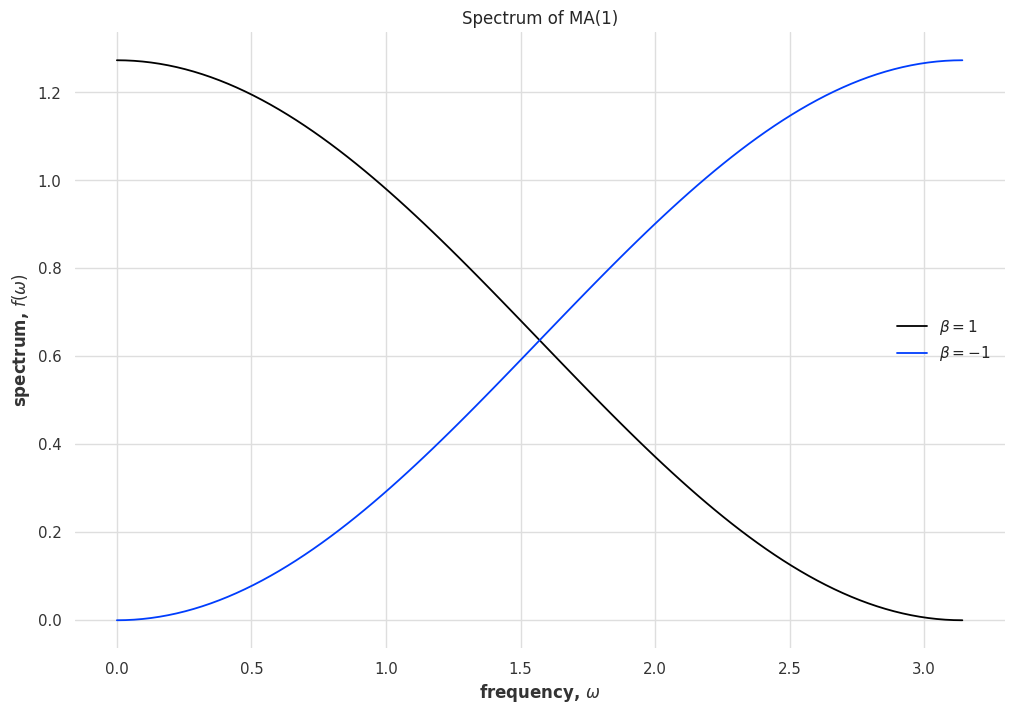

In [77]:
fig, ax = plt.subplots()
ax.plot(w, f_pos, label="$\\beta = 1$")
ax.plot(w, f_neg, label="$\\beta = -1$")
ax.set_xlabel("frequency, $\\omega$")
ax.set_ylabel("spectrum, $f(\\omega)$")
ax.set_title("Spectrum of MA(1)")
ax.legend();

## Example 3: spectrum of AR(1)

Consider $X_t = \alpha X_{t-1} + Z_t$. We know its ACVF $\gamma(k) = \sigma_X^2 \alpha^{|k|}$. Using
$$
    \begin{aligned}
    f(\omega) & = \frac1\pi \sum_{k=-\infty}^\infty \gamma(k) e^{- i\omega k} = \\
    & = \frac{\sigma_X^2}{\pi} \left( 1 + \sum_{k=1}^\infty \alpha^k e^{- i\omega k} + \sum_{k=1}^\infty \alpha^k e^{i\omega k} \right) = \\
    & = \frac{\sigma_X^2}{\pi} \left( 1 + \frac{\alpha e^{-i \omega}}{1 - \alpha e^{-i \omega}} + \frac{\alpha e^{i \omega}}{1 - \alpha e^{i \omega}} \right) = \\
    & = \frac{\sigma_X^2}{\pi} \frac{1 - \alpha^2}{1 - 2 \alpha \cos{\omega} + \alpha^2} = \frac{\sigma^2_Z}{\pi(1 - 2 \alpha \cos{\omega} + \alpha^2)}
    \end{aligned}
$$

In [78]:
w = np.linspace(0, np.pi, 100)
sigma_z = 1
alpha = 0.7
f_pos = sigma_z ** 2 / (np.pi * (1 - 2 * alpha * np.cos(w) + alpha ** 2))
f_neg = sigma_z ** 2 / (np.pi * (1 + 2 * alpha * np.cos(w) + alpha ** 2))

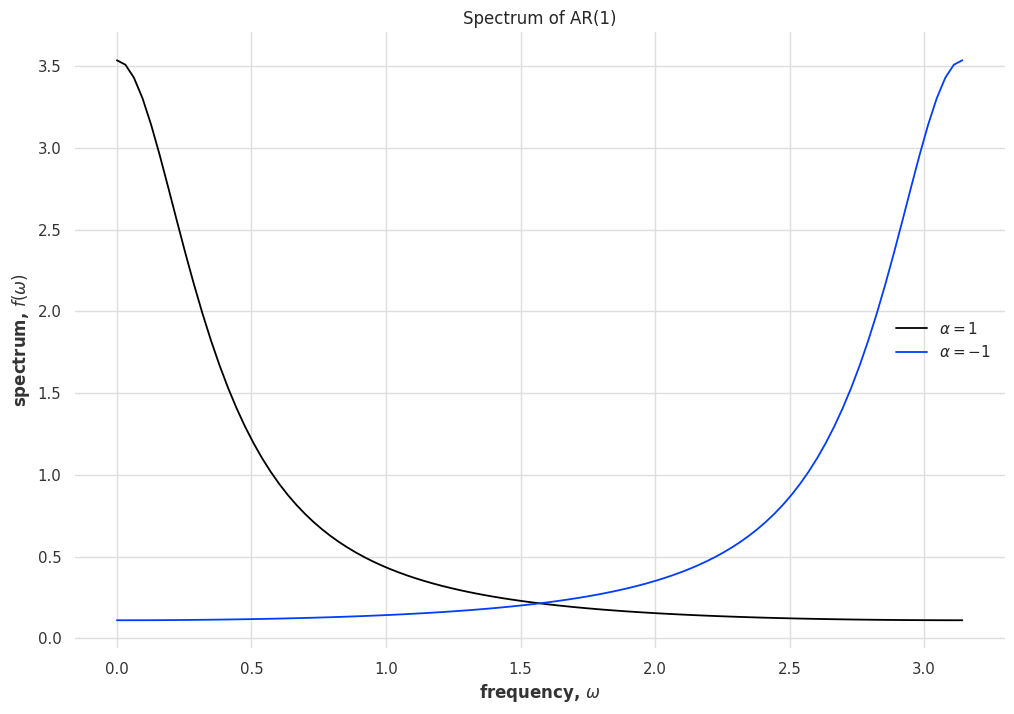

In [79]:
fig, ax = plt.subplots()
ax.plot(w, f_pos, label="$\\alpha = 1$")
ax.plot(w, f_neg, label="$\\alpha = -1$")
ax.set_xlabel("frequency, $\\omega$")
ax.set_ylabel("spectrum, $f(\\omega)$")
ax.set_title("Spectrum of AR(1)")
ax.legend();

## Example 4: spectrum of AR(2)

Consider $X_t = \alpha_1 X_{t-1} + \alpha_2 X_{t-2} + Z_t$.

Without derivation,
$$
 f(\omega) = \frac{\sigma^2_Z}{\pi \left( 1 + \alpha_1^2 + \alpha_2^2 - 2 \alpha_1 (1 - \alpha_2) \cos{\omega} - 2 \alpha_2 \cos{2\omega} \right)}
$$

In [80]:
def ar_2_f(w, sigma_z, alpha_1, alpha_2):
    return sigma_z ** 2 / (np.pi * (1 + alpha_1 ** 2 + alpha_2 ** 2 - 2 * alpha_1 * (1 - alpha_2) * np.cos(w) - 2 * alpha_2 * np.cos(2 * w)))

In [81]:
w = np.linspace(0, np.pi, 100)
sigma_z = 1
f_left = ar_2_f(w, sigma_z, 0.5, 0.1)
f_mid = ar_2_f(w, sigma_z, 0.5, -0.5)
f_right = ar_2_f(w, sigma_z, -0.5, 0.1)
f_mid_low = ar_2_f(w, sigma_z, 0.1, 0.5)

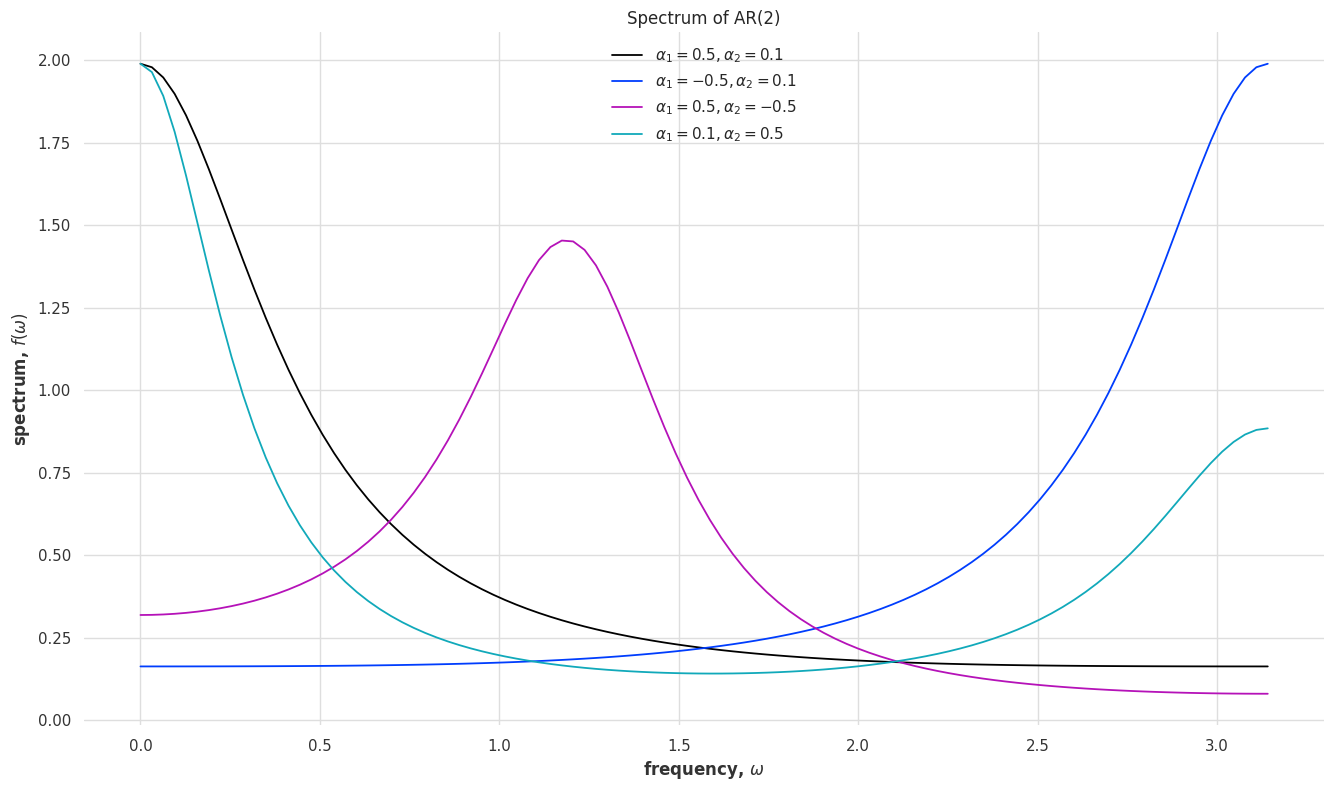

In [82]:
fig, ax = plt.subplots(figsize=(16,9))
ax.plot(w, f_left, label="$\\alpha_1 = 0.5, \\alpha_2 = 0.1$")
ax.plot(w, f_right, label="$\\alpha_1 = -0.5, \\alpha_2 = 0.1$")
ax.plot(w, f_mid, label="$\\alpha_1 = 0.5, \\alpha_2 = -0.5$")
ax.plot(w, f_mid_low, label="$\\alpha_1 = 0.1, \\alpha_2 = 0.5$")
ax.set_xlabel("frequency, $\\omega$")
ax.set_ylabel("spectrum, $f(\\omega)$")
ax.set_title("Spectrum of AR(2)")
ax.legend();

## Periodogram

$$
I(\omega) = \frac1T |\omega|^2
$$

Plot $I(\omega)$ vs $\omega$ is called periodogram.

Periodogram is the DFT of ACVF:
$$
I(\omega_p) = \frac1\pi \left( c_0 + 2 \sum_{k=1}^{T-1} c_k \cos{\omega_p k} \right)
$$

In [83]:
from scipy.signal import periodogram
from scipy.signal import find_peaks

In [85]:
from astsadata import cmort

In [88]:
cmort_ts = TimeSeries.from_series(cmort.set_index(
    pd.date_range(
        cmort.index[0].start_time.date(),
        periods=508,
        freq="W-MON",
        inclusive="both"
    )
)["value"])

<Axes: xlabel='time'>

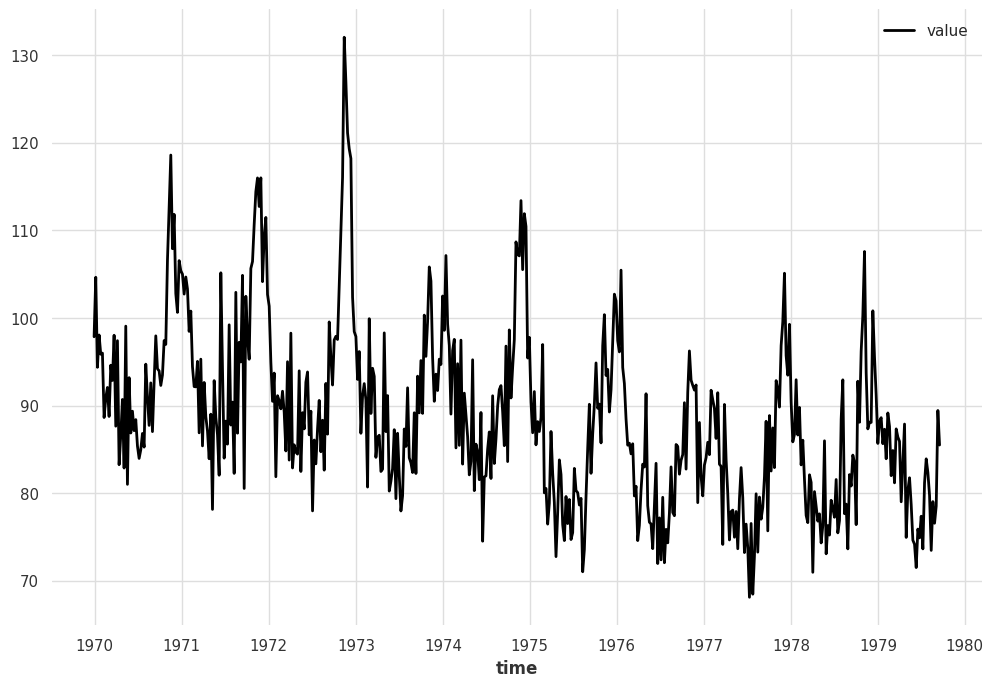

In [89]:
fig, ax = plt.subplots()
cmort_ts.plot(ax=ax)

In [90]:
freq, psd = periodogram(cmort_ts.values().flatten(), fs=52.18)

Text(0.5, 0, 'frequency, 1/years')

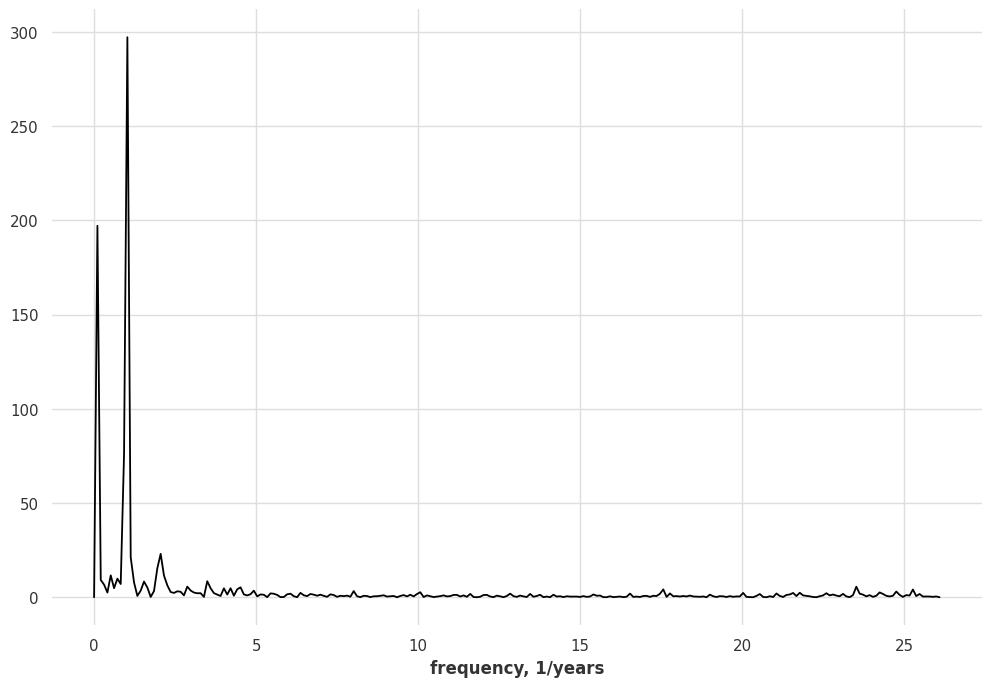

In [91]:
fig, ax = plt.subplots()
ax.plot(freq, psd)
ax.set_xlabel("frequency, 1/years")

In [92]:
freq[find_peaks(psd, threshold=50)[0]]

array([0.10271654, 1.02716535])

In [167]:
1 / np.array([0.10271654, 1.02716535])

array([9.73553042, 0.97355309])

In [93]:
cmort_sdiff_ts = cmort_ts.diff(52)

<Axes: xlabel='time'>

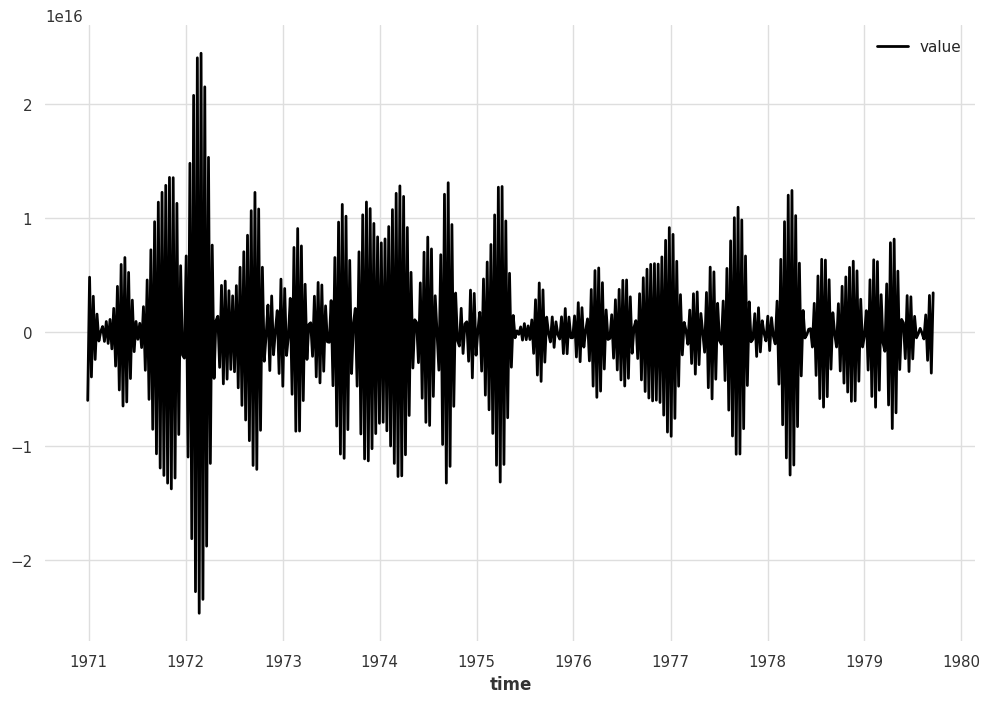

In [94]:
fig, ax = plt.subplots()
cmort_sdiff_ts.plot(ax=ax)

In [95]:
freq2, psd2 = periodogram(cmort_sdiff_ts.values().flatten(), fs=52.18)

Text(0.5, 0, 'frequency, 1/years')

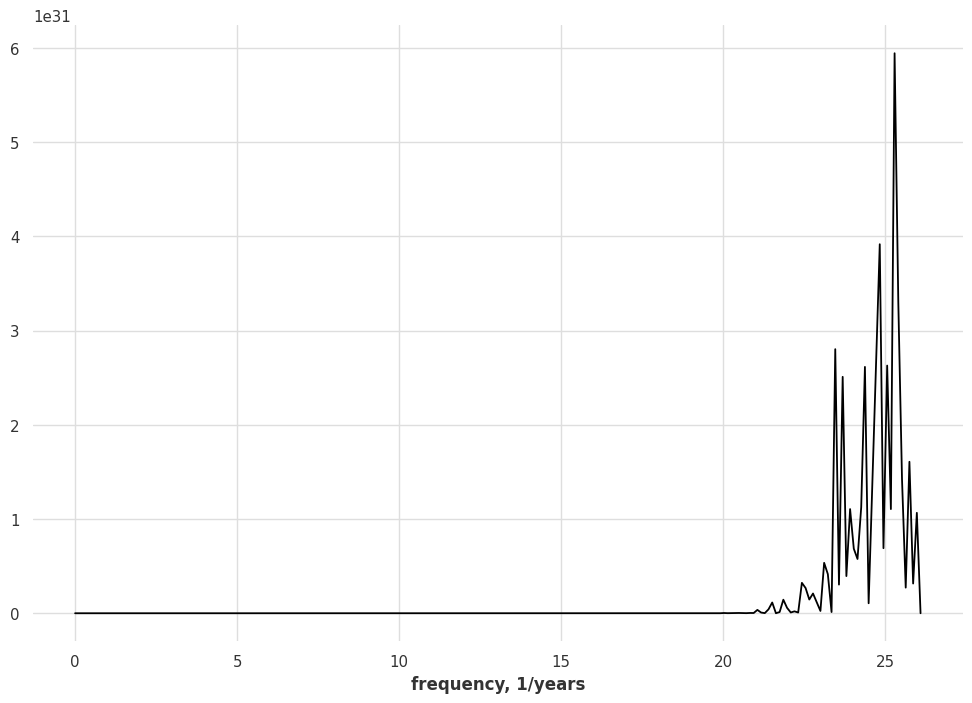

In [96]:
fig, ax = plt.subplots()
ax.plot(freq2, psd2)
ax.set_xlabel("frequency, 1/years")

In [172]:
freq[find_peaks(psd2, threshold=3e30)[0]]

array([21.05688976, 21.26232283, 21.46775591, 21.87862205, 22.28948819,
       22.49492126, 22.70035433, 23.11122047, 23.31665354])

In [174]:
52.18 / np.array([21.05688976, 21.26232283, 21.46775591, 21.87862205, 22.28948819, 22.49492126, 22.70035433, 23.11122047, 23.31665354])

array([2.47804878, 2.45410628, 2.43062201, 2.38497653, 2.34101382,
       2.3196347 , 2.29864253, 2.25777778, 2.23788546])

Text(0.5, 0, 'period, weeks')

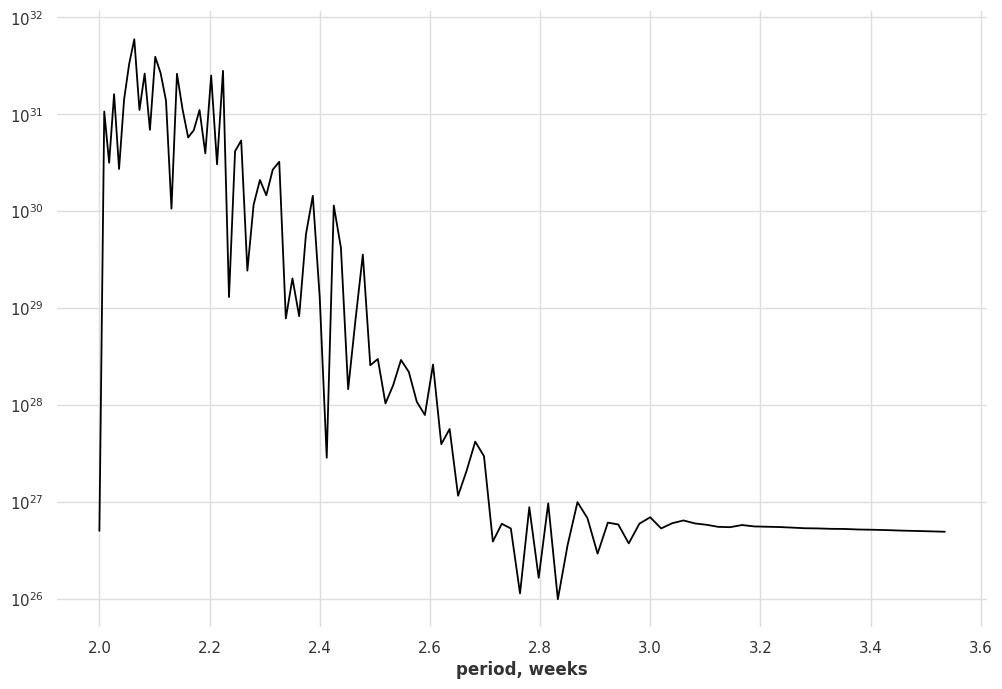

In [97]:
fig, ax = plt.subplots()
ax.semilogy(52.18/freq2[-100:], psd2[-100:])
ax.set_xlabel("period, weeks")

In [177]:
freq3, psd3 = periodogram(salaries_ts.values().flatten(), fs=1)

Text(0.5, 0, 'frequency, 1/months')

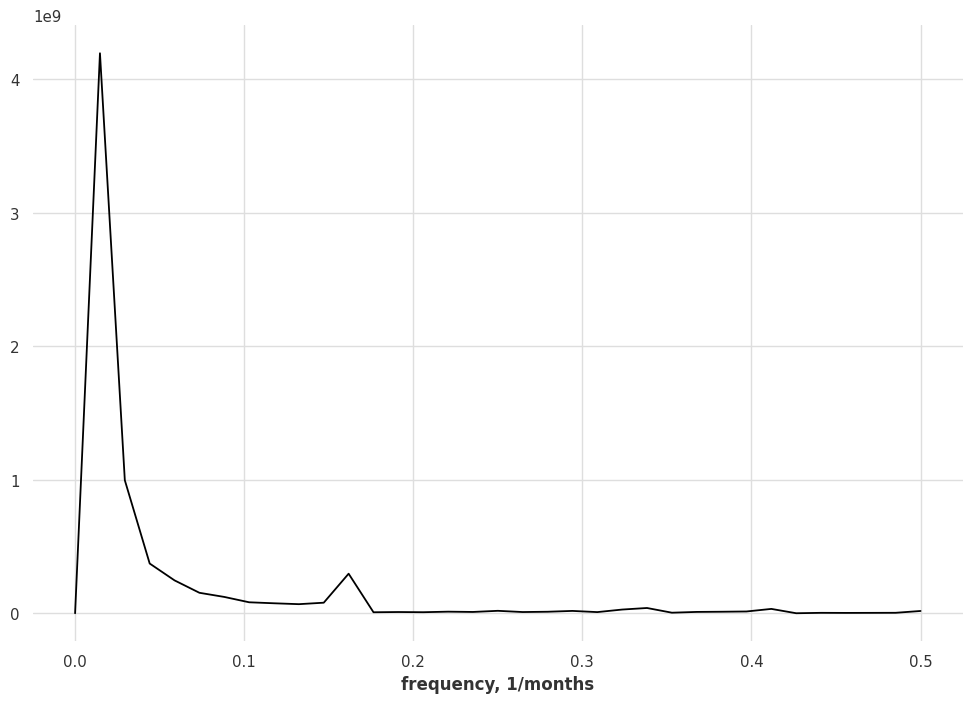

In [178]:
fig, ax = plt.subplots()
ax.plot(freq3, psd3)
ax.set_xlabel("frequency, 1/months")

In [180]:
freq[find_peaks(psd3, threshold=1e9)[0]]

array([0.10271654])

In [181]:
1 / np.array([0.10271654])

array([9.73553042])

In [187]:
check_seasonality(salaries_ts)

(True, np.int64(12))

## Changepoint detection

A **change point** is the change of the statistical properties of the series. The change point detection problem is to identify the change moment.

<table>
    <tr>
        <td><img src="ex-1-1.png" widh=150px</td>
        <td><img src="ex-1-2.png" widh=150px</td>
    </tr>
    <tr>
        <td><img src="ex-1-3.png" widh=150px</td>
        <td><img src="ex-1-4.png" widh=150px</td>
    </tr>
</table>

In [98]:
!pip install ruptures

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 25.1 MB/s eta 0:00:00


In [100]:
import ruptures as rpt

[87, 173, 259, 340, 420, 500]


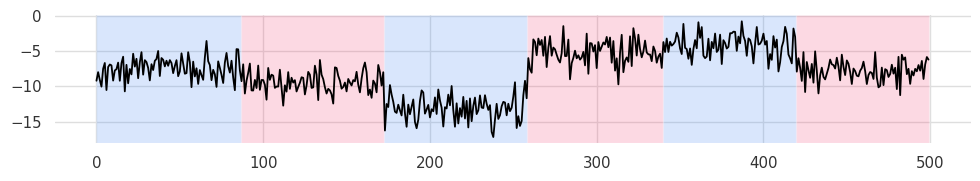

In [101]:
n_samples, n_dims, sigma = 500, 1, 1.5
n_cps = 5
signal, cps = rpt.pw_constant(n_samples, n_dims, n_cps, noise_std=sigma, seed=27)
print(cps)
rpt.display(signal, cps);

## Models

Considered models are detecting changes in mean of the underlying process:
- Binseg: splits initial task into a sequence of CPD tasks with AMOC (at most one changepoint) assumption
- Dynp: same but uses dynamic programming
- PELT: uses cost function with penalty
- KernelCPD: maps signal into RKHS and performs CPD there

Each of these methods can have different cost functions.

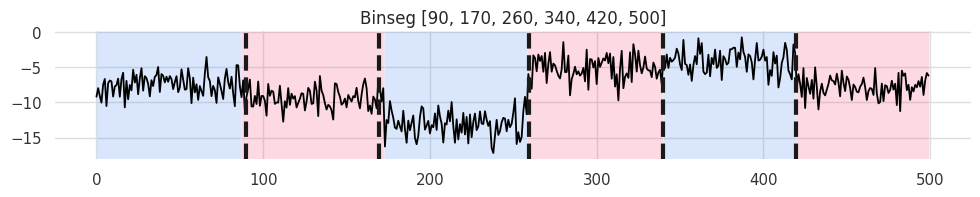

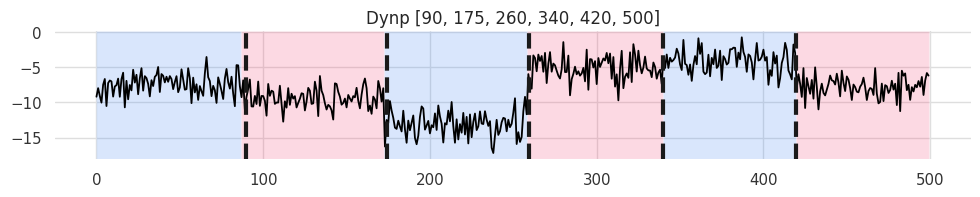

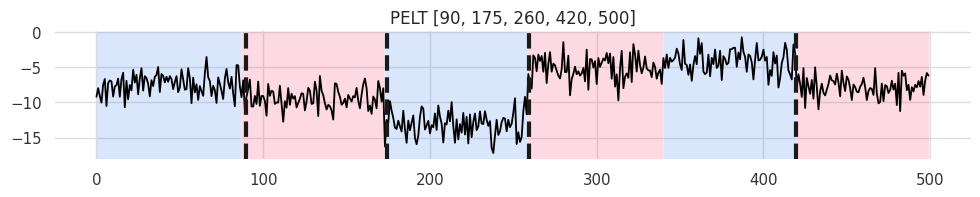

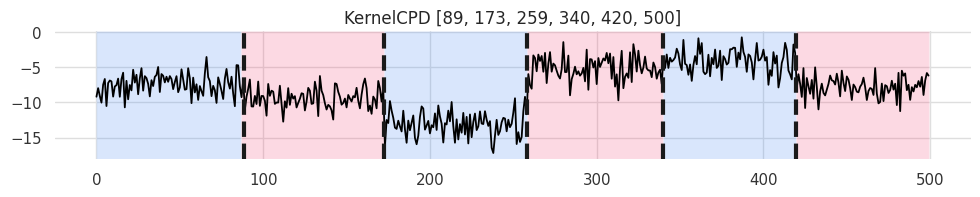

In [102]:
results_dict = dict()

algo = rpt.Binseg(model="l2").fit(signal)
result_binseg = algo.predict(n_bkps=n_cps)
results_dict["binseg"] = result_binseg

fig, ax = rpt.display(signal, cps, result_binseg)
ax[0].set_title(f"Binseg {result_binseg}")

algo = rpt.Dynp(model="l2").fit(signal)
result_dynp = algo.predict(n_bkps=n_cps)
results_dict["dynp"] = result_dynp

fig, ax = rpt.display(signal, cps, result_dynp)
ax[0].set_title(f"Dynp {result_dynp}")

algo = rpt.Pelt(model="l2").fit(signal)
result_pelt = algo.predict(pen=50)
results_dict["pelt"] = result_pelt

fig, ax = rpt.display(signal, cps, result_pelt)
ax[0].set_title(f"PELT {result_pelt}")

algo = rpt.KernelCPD(kernel="rbf").fit(signal)
result_kernel = algo.predict(n_bkps=n_cps)
results_dict["kernel"] = result_kernel

fig, ax = rpt.display(signal, cps, result_kernel)
ax[0].set_title(f"KernelCPD {result_kernel}");

## Evaluation

1. **Classification** metrics with specific interpretation of Confusion Matrix elements. Let $\tau$ be the predicted CP and $\theta$ - the true one, then detection is True Positive if $|\tau - \theta| < m$ for some margin $m$.

2. **Clustering** metrics measure similarity of 2 partitionings of a time series: one made by the true CPs and one made by the predicted ones.

3. **CPD** specific metrics, e.g. Detection Delay, Time for False Alarm, Area under the Detection Curve, not present in `ruptures`.

In [104]:
from ruptures.metrics import precision_recall, hausdorff, randindex

In [105]:
pd.DataFrame({
    model: [
        *precision_recall(cps, preds, margin=10),
        hausdorff(cps, preds),
        randindex(cps, preds)
    ]
    for model, preds in results_dict.items()
}, index=["Precision", "Recall", "Hausdorff metric", "Rand index"])

,binseg,dynp,pelt,kernel
Precision,1.000000,1.00000,1.000000,1.000000
Recall,1.000000,1.00000,0.800000,1.000000
Hausdorff metric,3.000000,3.00000,80.000000,2.000000
Rand index,0.990565,0.99192,0.940617,0.997259


## Real data

This is a dataset of pixel locations in 2D and angle differences of bee movements.

In [107]:
import scipy.io as sio

In [108]:
data_raw = sio.loadmat("beedance.mat")
data = data_raw['Y']
target = data_raw['L']
cps = list(np.where(target.flatten() != 0)[0])
cps.append(len(target))

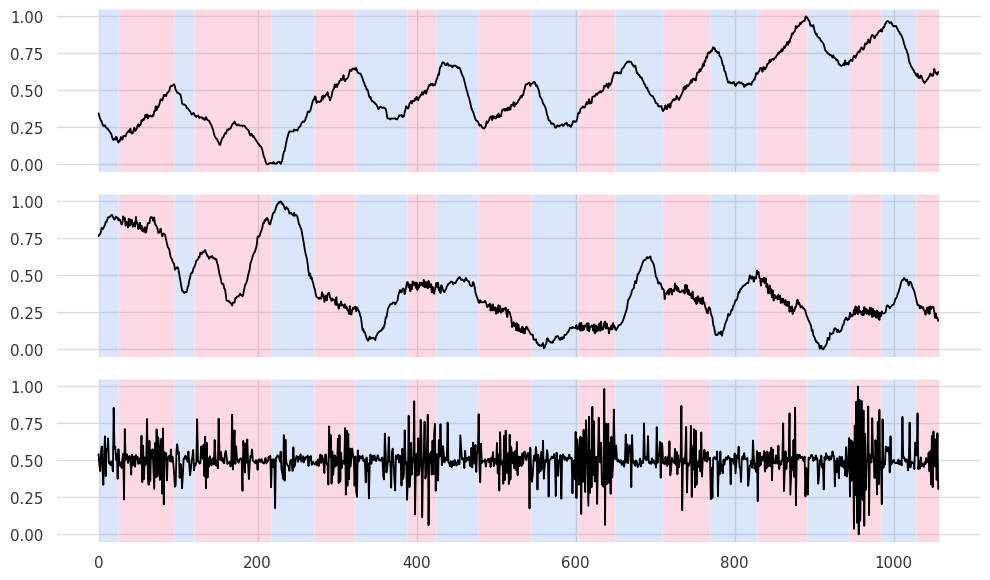

In [109]:
rpt.display(data, cps);

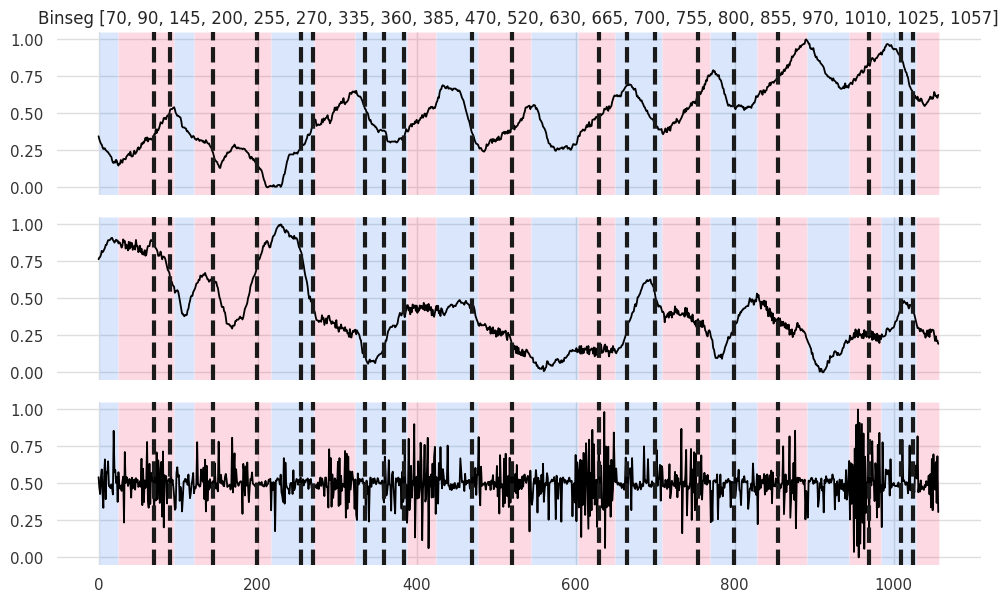

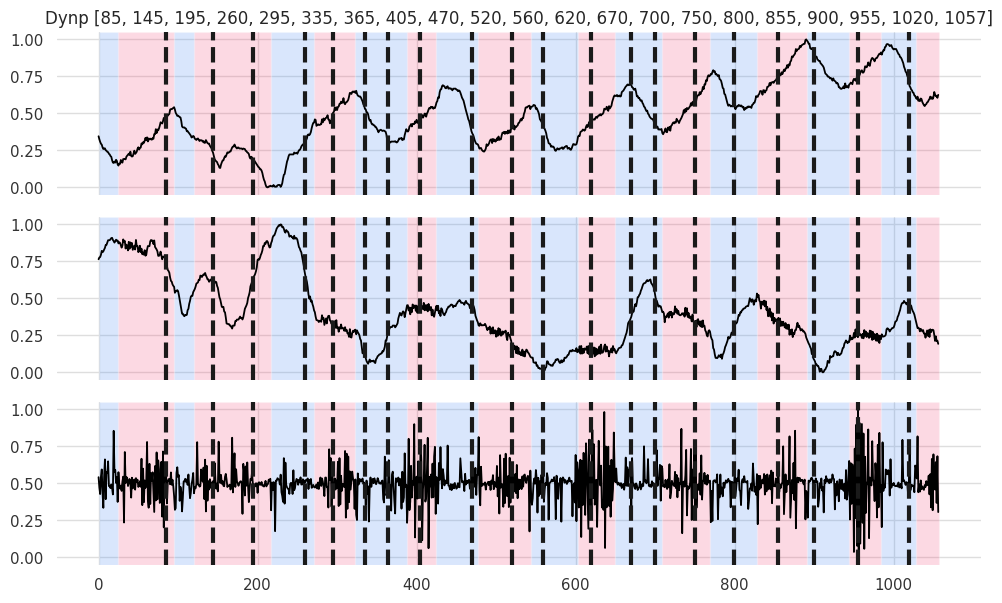

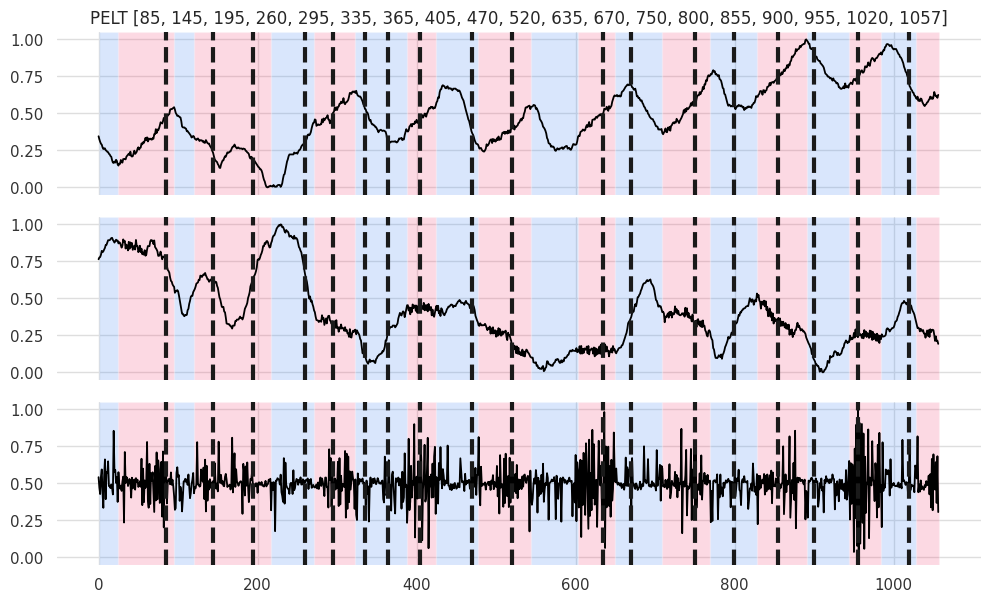

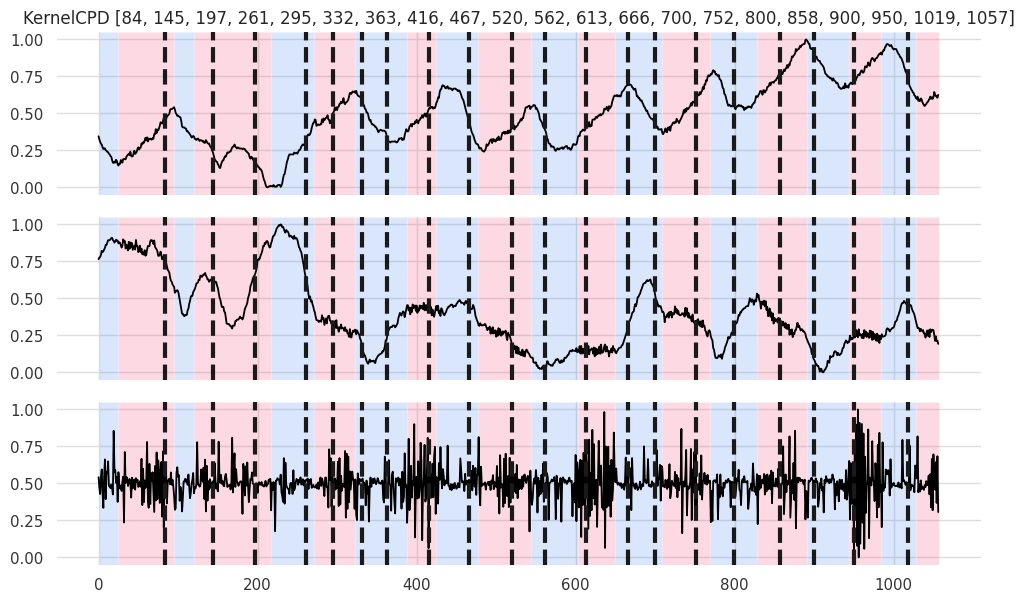

In [110]:
n_cps = len(cps)
results_dict = dict()

algo = rpt.Binseg(model="l2").fit(data)
result_binseg = algo.predict(n_bkps=n_cps)
results_dict["binseg"] = result_binseg

fig, ax = rpt.display(data, cps, result_binseg)
ax[0].set_title(f"Binseg {result_binseg}")

algo = rpt.Dynp(model="l2").fit(data)
result_dynp = algo.predict(n_bkps=n_cps)
results_dict["dynp"] = result_dynp

fig, ax = rpt.display(data, cps, result_dynp)
ax[0].set_title(f"Dynp {result_dynp}")

algo = rpt.Pelt(model="l2").fit(data)
result_pelt = algo.predict(pen=0.7)
results_dict["pelt"] = result_pelt

fig, ax = rpt.display(data, cps, result_pelt)
ax[0].set_title(f"PELT {result_pelt}")

algo = rpt.KernelCPD(kernel="rbf").fit(data)
result_kernel = algo.predict(n_bkps=n_cps)
results_dict["kernel"] = result_kernel

fig, ax = rpt.display(data, cps, result_kernel)
ax[0].set_title(f"KernelCPD {result_kernel}");

In [111]:
pd.DataFrame({
    model: [
        *precision_recall(cps, preds, margin=10),
        hausdorff(cps, preds),
        randindex(cps, preds)
    ]
    for model, preds in results_dict.items()
}, index=["Precision", "Recall", "Hausdorff metric", "Rand index"])

,binseg,dynp,pelt,kernel
Precision,0.300000,0.200000,0.166667,0.250000
Recall,0.315789,0.210526,0.157895,0.263158
Hausdorff metric,45.000000,60.000000,60.000000,59.000000
Rand index,0.949469,0.955380,0.950186,0.956989


## CUSUM

In [112]:
data_raw = sio.loadmat("fishkiller.mat")
data = data_raw['Y']
target = data_raw['L']
subseq_len = 5000
data, target = data[:subseq_len], target[:subseq_len]
cps = list(np.where(np.diff(target.flatten()) != 0)[0])
cps.append(len(target))

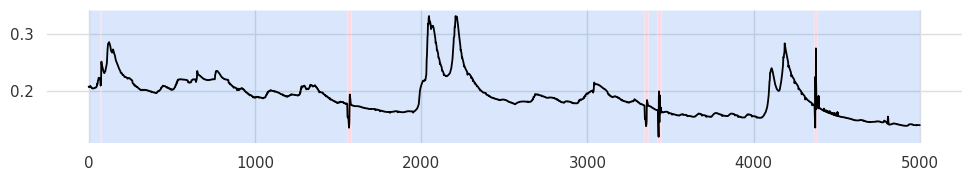

In [113]:
rpt.display(data, cps);

In [114]:
def cusum(data, threshold, drift=0):
    """
    Detects changes in the mean of a signal using the CUSUM method.

    Parameters:
        data (list or np.ndarray): The input time series data.
        threshold (float): The threshold value for detecting a change.
        drift (float): Drift parameter to adjust sensitivity to small changes (default: 0).

    Returns:
        list: indexes of changepoints
    """
    # Initialize variables
    g_pos = [0]  # Positive cumulative sum
    g_neg = [0]  # Negative cumulative sum
    signals = [0] * len(data)  # To store detection signals

    for i in range(1, len(data)):
        # Update positive and negative cumulative sums
        delta = data[i] - data[i - 1]
        g_pos.append(max(0, g_pos[-1] + delta - drift))
        g_neg.append(max(0, g_neg[-1] - delta - drift))

        # Detect change if threshold is exceeded
        if g_pos[-1] > threshold or g_neg[-1] > threshold:
            signals[i] = 1
            g_pos[-1], g_neg[-1] = 0, 0  # Reset after detection

    return list(np.where(signals)[0]) + [len(data)]

In [115]:
result_cusum = cusum(data, 0.09)

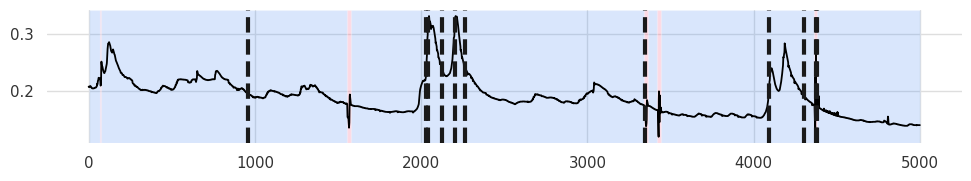

In [116]:
rpt.display(data, cps, result_cusum);

In [117]:
pd.DataFrame({
    model: [
        *precision_recall(cps, preds, margin=10),
        hausdorff(cps, preds),
        randindex(cps, preds)
    ]
    for model, preds in {"CUSUM": result_cusum}.items()
}, index=["Precision", "Recall", "Hausdorff metric", "Rand index"])

,CUSUM
Precision,0.181818
Recall,0.200000
Hausdorff metric,888.000000
Rand index,0.838861


## More complex data

In [118]:
!pip install librosa

In [119]:
import librosa
import librosa.display

from IPython.display import Audio, display

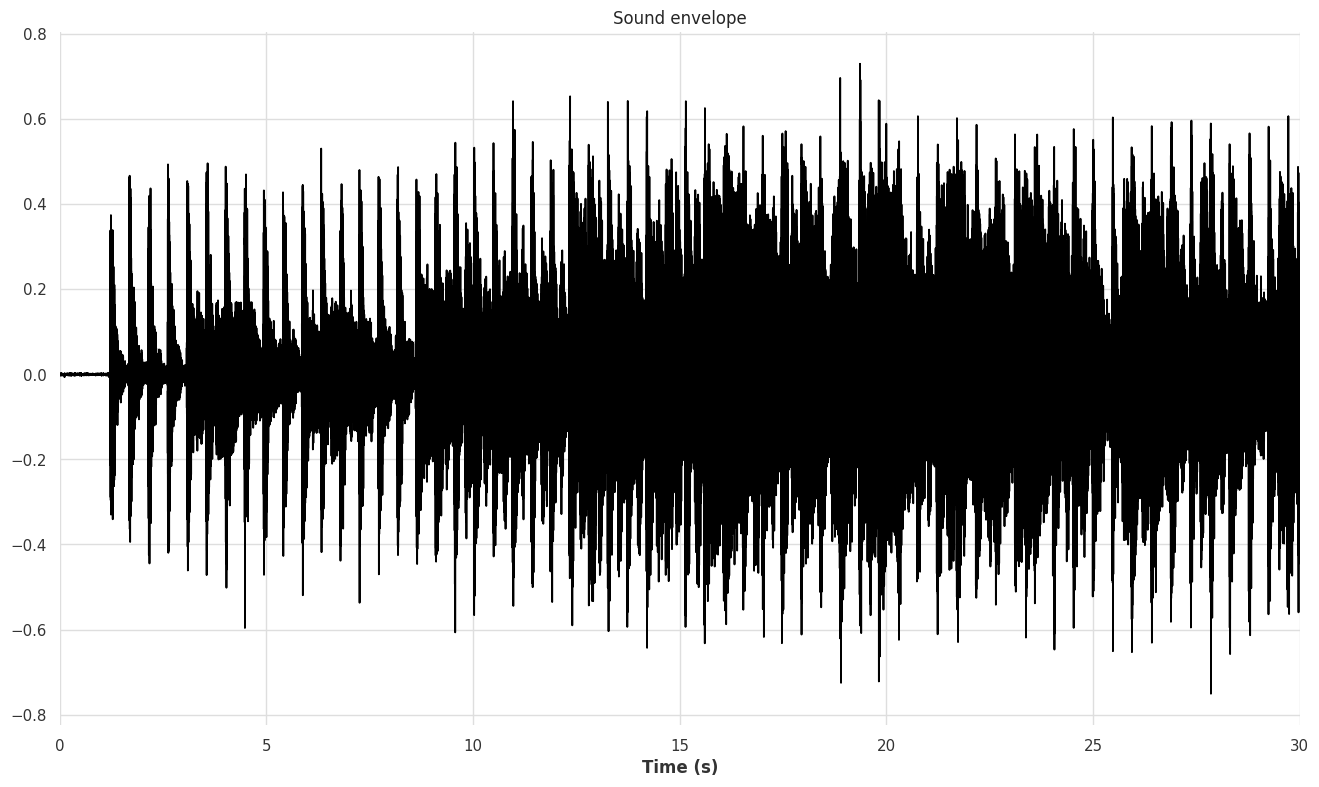

In [121]:
duration = 20
signal, sampling_rate = librosa.load("pretty_woman.mp3", duration=duration)

display(Audio(data=signal, rate=sampling_rate))

fig, ax = plt.subplots(figsize=(16,9))
ax.plot(np.arange(signal.size) / sampling_rate, signal)
ax.set_xlim(0, signal.size / sampling_rate)
ax.set_xlabel("Time (s)")
_ = ax.set(title="Sound envelope")

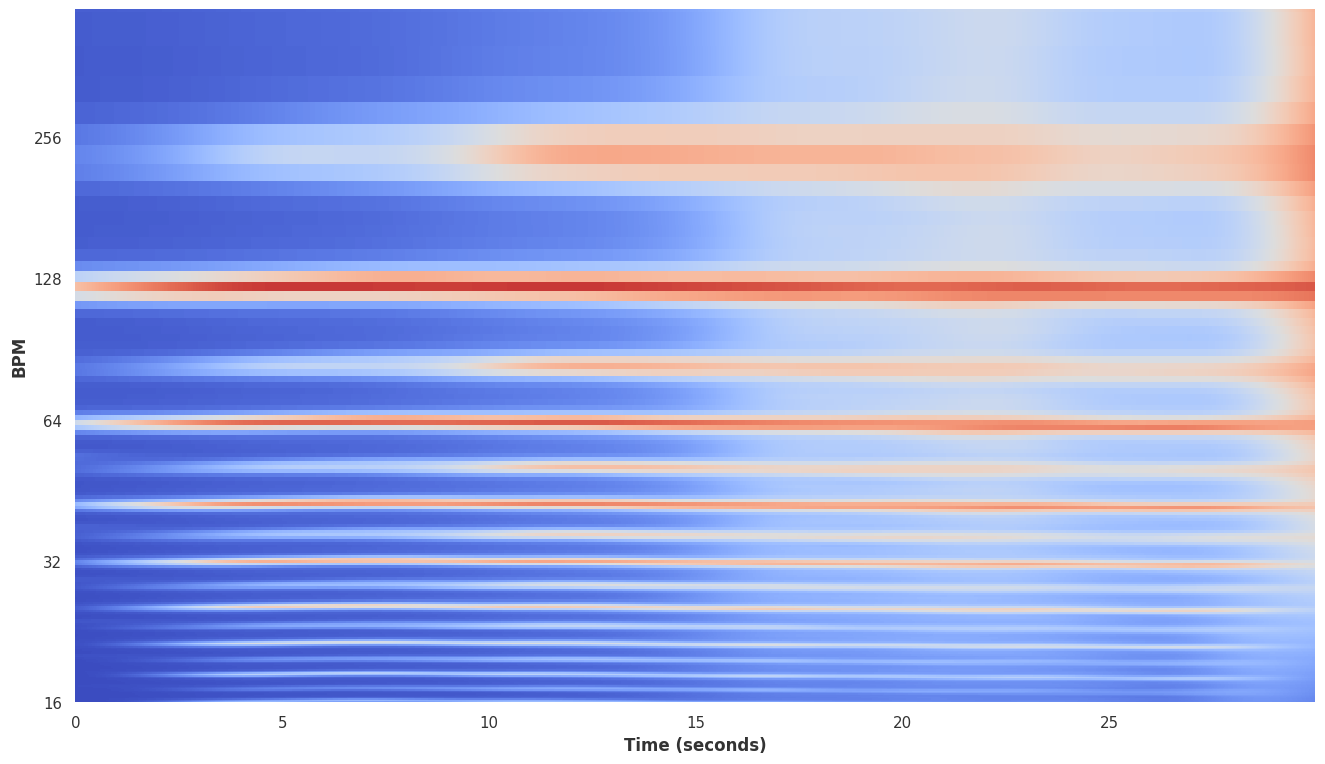

In [122]:
oenv = librosa.onset.onset_strength(
    y=signal, sr=sampling_rate
)

tempogram = librosa.feature.tempogram(
    onset_envelope=oenv,
    sr=sampling_rate
)

fig, ax = plt.subplots(figsize=(16,9))
librosa.display.specshow(
    tempogram,
    ax=ax,
    sr=sampling_rate,
    x_axis="s",
    y_axis="tempo"
);

(0.0, 21.0)

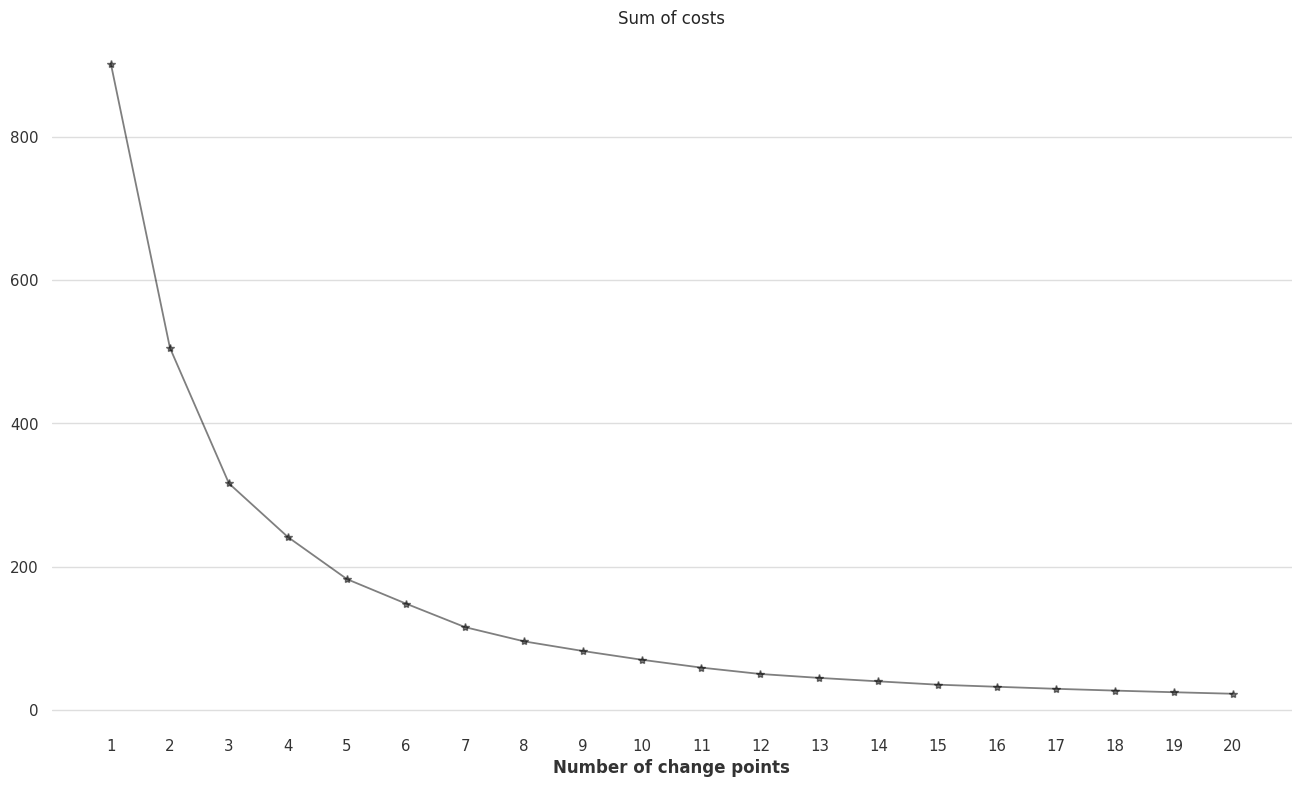

In [123]:
algo = rpt.KernelCPD(kernel="linear").fit(tempogram.T)

n_cps_max = 20
algo.predict(n_cps_max);

array_of_n_cps = np.arange(1, n_cps_max + 1)

fig, ax = plt.subplots(figsize=(16,9))
ax.plot(
    array_of_n_cps,
    [algo.cost.sum_of_costs(algo.predict(n_bkps=n_cps)) for n_cps in array_of_n_cps],
    "-*",
    alpha=0.5,
)
ax.set_xticks(array_of_n_cps)
ax.set_xlabel("Number of change points")
ax.set_title("Sum of costs")
ax.grid(axis="x")
ax.set_xlim(0, n_cps_max + 1)

In [124]:
n_cps = 5

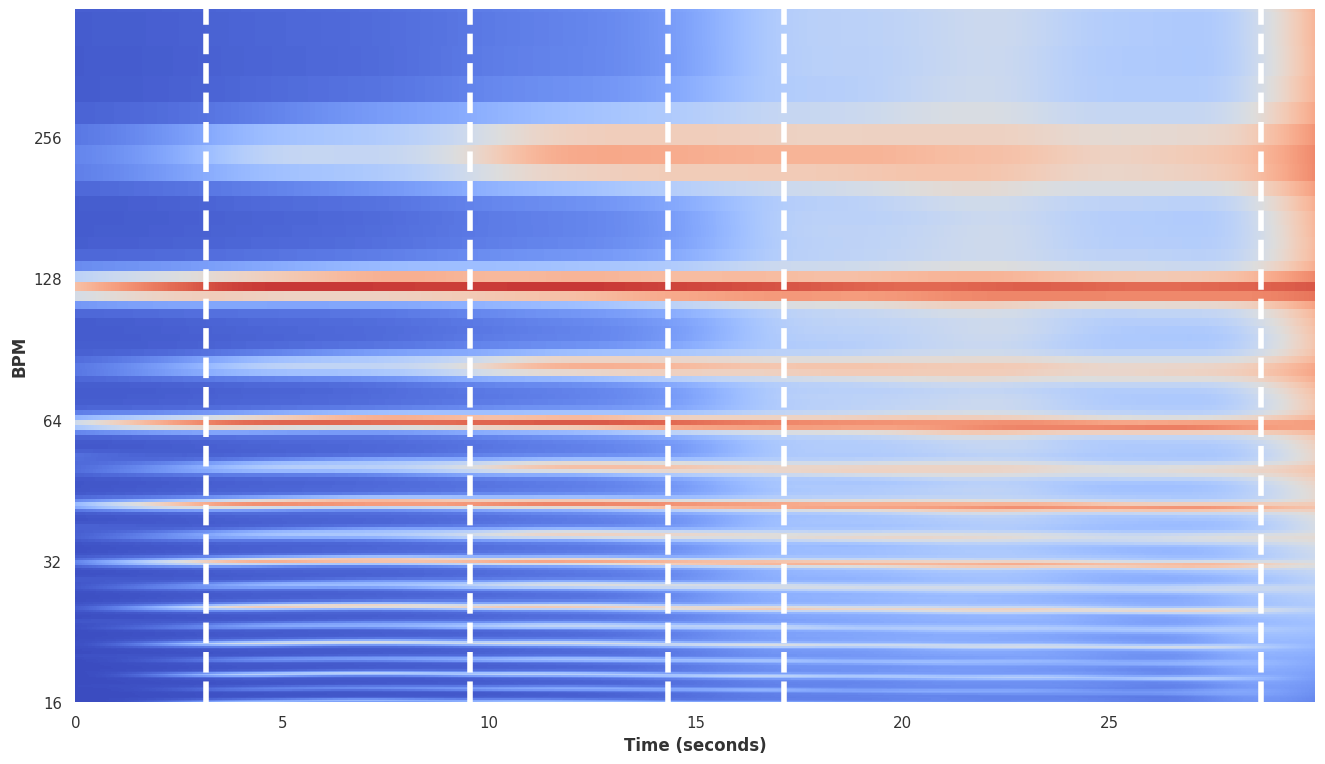

In [125]:
cps = algo.predict(n_bkps=n_cps)
cps_times = librosa.frames_to_time(cps, sr=sampling_rate)

# Displaying results
fig, ax = plt.subplots(figsize=(16,9))
librosa.display.specshow(
    tempogram,
    ax=ax,
    x_axis="s",
    y_axis="tempo",
    sr=sampling_rate,
)

for b in cps_times[:-1]:
    ax.axvline(b, ls="--", color="white", lw=4)

In [126]:
cps_time_indexes = (sampling_rate * cps_times).astype(int).tolist()

for (segment_number, (start, end)) in enumerate(
    rpt.utils.pairwise([0] + cps_time_indexes), start=1
):
    segment = signal[start:end]
    display(Audio(data=segment, rate=sampling_rate))

## NN methods

Classical CPD methods can't be directly applied to complex unstructured data like videos. In order to work with such data, we can proceed in two ways:
1. Get representations and apply classical CPD on top of them
2. Develop and end-to-end NN solution for CPD